In [11]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd

In [12]:
def calculate_returns(prob,asset):
    expected_return = np.sum(prob*asset)
    expected_var    = np.sum(prob*(asset - expected_return)**2)
    return expected_return, expected_var

In [13]:
scenarios = pd.DataFrame()

In [26]:
scenarios['Scenario'] = [1,2,3]
scenarios['Probs']    = [1/3,1/3,1/3]
scenarios['R1']       = [15,9,3]
scenarios['R2']       = [6,6,12]

In [27]:
scenarios

,Scenario,Probs,R1,R2
0,1,0.333333,15,6
1,2,0.333333,9,6
2,3,0.333333,3,12


In [28]:
Ex_R1, VarR1 = calculate_returns(scenarios['Probs'],scenarios['R1'])
Ex_R2, VarR2 = calculate_returns(scenarios['Probs'],scenarios['R2'])
print(f'Expected return Asset1 = {Ex_R1:.3f} +/- {VarR1**0.5:.3f}')
print(f'Expected return Asset2 = {Ex_R2:.3f} +/- {VarR2**0.5:.3f}')
print(f'Variance of Asset1 = {VarR1:.4f}')
print(f'Variance of Asset2 = {VarR2:.4f}')

Expected return Asset1 = 9.000 +/- 4.899
Expected return Asset2 = 8.000 +/- 2.828
Variance of Asset1 = 24.0000
Variance of Asset2 = 8.0000


In [29]:
W1 = 0.5
W2 = 1 - W1
Ex_P1, VarP1 = calculate_returns(scenarios['Probs'],W1*scenarios['R1']+W2*scenarios['R2'])
print(Ex_P1, VarP1)

8.5 1.9999999999999998


In [30]:
Ex_Ps = []
VarPs = []
W1s   = np.arange(0,1+0.1,0.1)
for W1 in W1s:
    W2 = 1 - W1
    A, B = calculate_returns(scenarios['Probs'],W1*scenarios['R1']+W2*scenarios['R2'])
    Ex_Ps.append(A)
    VarPs.append(B)
Ex_Ps = np.array(Ex_Ps)
VarPs = np.array(VarPs)

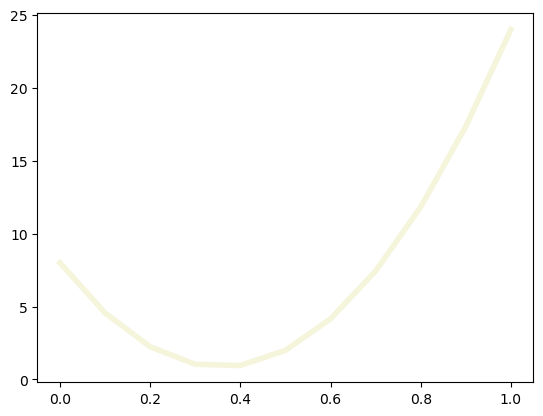

In [31]:
plt.plot(W1s,VarPs,color="#f5f5dc",linewidth=4)